<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report

In [40]:
df = pd.read_csv('heart.csv')

In [41]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


In [43]:
df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


Text(0.5, 1.0, 'Age-Cholesterol plot')

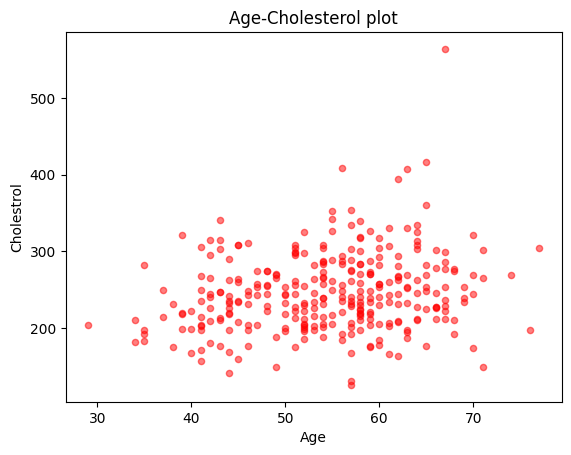

In [44]:
df.plot(kind='scatter', x='Age', y='Chol', alpha = 0.5, c='r')
plt.xlabel('Age')
plt.ylabel('Cholestrol')
plt.title('Age-Cholesterol plot')


In [45]:
df_new = pd.get_dummies(df, columns = ['ChestPain', 'Thal'], drop_first=True)

In [46]:
X = df_new.drop('AHD', axis=1)
y = df_new['AHD']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [48]:
X_train.isna().sum()

,0
Age,0
Sex,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0
Oldpeak,0
Slope,0


In [49]:
X_train.dtypes

,0
Age,int64
Sex,int64
RestBP,int64
Chol,int64
Fbs,int64
RestECG,int64
MaxHR,int64
ExAng,int64
Oldpeak,float64
Slope,int64


In [51]:
X_train["Ca"] = X_train["Ca"].fillna(X_train["Ca"].median())
X_test["Ca"] = X_test["Ca"].fillna(X_train["Ca"].median())

In [52]:
from sklearn.model_selection import GridSearchCV

ml = svm.SVC()
para_grid = {'C': [1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']}
grid = GridSearchCV(ml, para_grid, refit=True, verbose=1, cv=5, n_jobs=-1)
grid_search = grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [59]:
print(grid_search.best_params_)

{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


In [60]:
accuracy = grid_search.best_score_
accuracy

np.float64(0.6696428571428571)

In [62]:
y_test_hat = grid.predict(X_test)

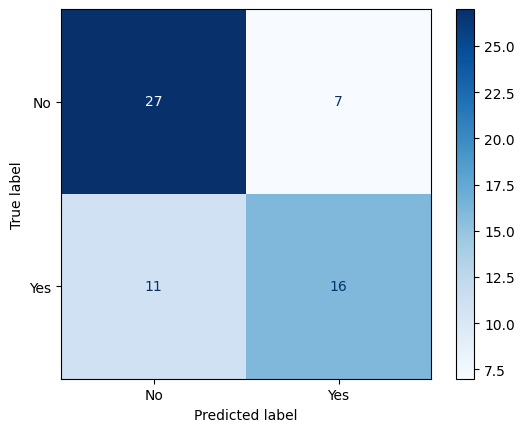

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
confusion_mat = confusion_matrix(y_test, y_test_hat)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=grid.classes_)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.show()

In [66]:
print(classification_report(y_test, y_test_hat))

              precision    recall  f1-score   support

          No       0.71      0.79      0.75        34
         Yes       0.70      0.59      0.64        27

    accuracy                           0.70        61
   macro avg       0.70      0.69      0.70        61
weighted avg       0.70      0.70      0.70        61

